# 03 — Classification Algorithms

Classification predicts a **discrete category**. This notebook covers the
core classifiers you'll reach for most often, each with: theory → sklearn
implementation → evaluation → visualization.

We use two datasets throughout:
- **`load_breast_cancer`** (bundled, 30 features, binary) for realistic metrics/comparison.
- A small **synthetic 2D dataset** (`make_moons`) purely so we can *see* each
  algorithm's decision boundary — something impossible to plot directly in
  30 dimensions.

**Algorithms covered:**
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Naive Bayes
4. Decision Trees
5. Support Vector Machines (SVM)
6. Random Forest
7. Side-by-side model comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(2)

# --- Main benchmark dataset: breast cancer (real, bundled, binary) ---
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

results = {}

def evaluate(name, model, X_tr=X_train_s, X_te=X_test_s, y_tr=y_train, y_te=y_test):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else pred
    row = {
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
    }
    results[name] = row
    print(f"{name:>20}: " + "  ".join(f"{k}={v:.3f}" for k, v in row.items()))
    return model, pred

# --- Secondary dataset: 2D synthetic, only for visualizing decision boundaries ---
X2, y2 = make_moons(n_samples=300, noise=0.25, random_state=2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=2)

def plot_boundary(model, ax, title):
    model.fit(X2_train, y2_train)
    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, cmap="coolwarm", edgecolor="k", s=20)
    acc = model.score(X2_test, y2_test)
    ax.set_title(f"{title}\n(2D test accuracy={acc:.2f})")
    ax.set_xticks([]); ax.set_yticks([])

## 1. Logistic Regression

**Theory.** Despite the name, this is a classifier: it fits a linear
combination of features, then squashes it through the **sigmoid** function
`σ(z) = 1 / (1 + e^-z)` to output a probability in [0, 1]. The decision
boundary is linear in feature space. Trained by maximizing likelihood
(equivalently, minimizing log loss).

**Pros:** fast, interpretable, well-calibrated probabilities. **Cons:**
can't capture non-linear boundaries without feature engineering.

In [2]:
from sklearn.linear_model import LogisticRegression

evaluate("Logistic Regression", LogisticRegression(max_iter=5000))

 Logistic Regression: accuracy=0.982  precision=0.973  recall=1.000  f1=0.986  roc_auc=0.996


(LogisticRegression(max_iter=5000),
 array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
        1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 1]))

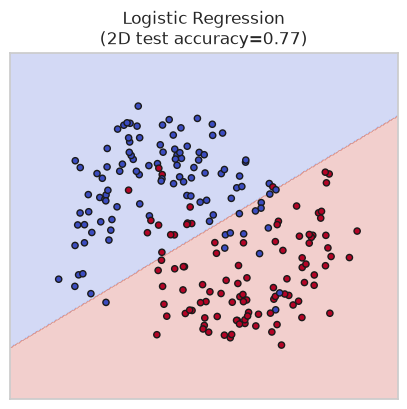

In [3]:
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_boundary(LogisticRegression(), ax, "Logistic Regression")
plt.show()

Notice the boundary is a straight line — logistic regression can only ever
draw a single hyperplane, so it struggles with the crescent ("moons") shape
here. Every following algorithm handles this non-linear boundary better.

## 2. K-Nearest Neighbors (KNN)

**Theory.** A purely instance-based ("lazy") method: to classify a new
point, find the `k` closest training points (by e.g. Euclidean distance) and
take a majority vote. No training phase at all — all the work happens at
prediction time. **Very sensitive to feature scaling** (always scale first)
and to the choice of `k`: small `k` → low bias/high variance (jagged
boundary), large `k` → high bias/low variance (smoother, can underfit).

In [4]:
from sklearn.neighbors import KNeighborsClassifier

evaluate("KNN (k=5)", KNeighborsClassifier(n_neighbors=5))

           KNN (k=5): accuracy=0.982  precision=0.973  recall=1.000  f1=0.986  roc_auc=0.973


(KNeighborsClassifier(),
 array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
        1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 1]))

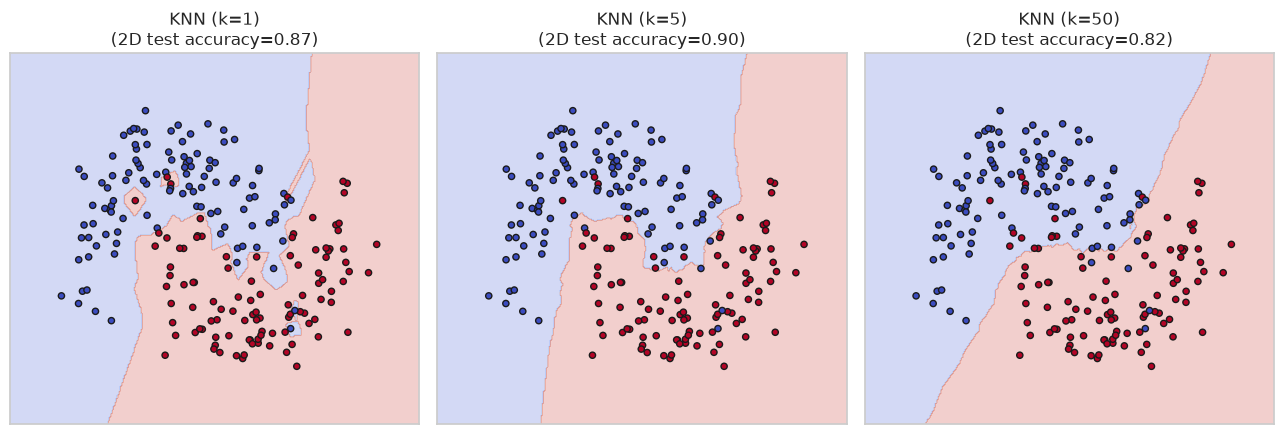

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, k in zip(axes, [1, 5, 50]):
    plot_boundary(KNeighborsClassifier(n_neighbors=k), ax, f"KNN (k={k})")
plt.tight_layout()
plt.show()

`k=1` produces a jagged, overfit boundary that chases individual noisy
points; `k=50` smooths so much it starts underfitting the crescent shape.
`k=5` is a reasonable middle ground here — in practice, pick `k` via
cross-validation (see `06_model_selection_tuning`).

## 3. Naive Bayes

**Theory.** Applies Bayes' theorem with a "naive" assumption: features are
conditionally independent given the class. `GaussianNB` models each feature
within each class as a Gaussian. Despite the (usually false) independence
assumption, it works surprisingly well in practice, is extremely fast, and
needs very little training data.

In [6]:
from sklearn.naive_bayes import GaussianNB

evaluate("Naive Bayes", GaussianNB())

         Naive Bayes: accuracy=0.965  precision=0.947  recall=1.000  f1=0.973  roc_auc=0.997


(GaussianNB(),
 array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 1]))

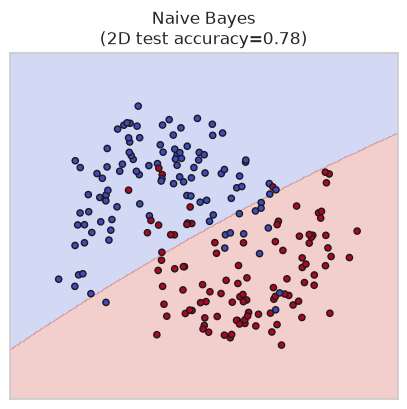

In [7]:
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_boundary(GaussianNB(), ax, "Naive Bayes")
plt.show()

## 4. Decision Trees

**Theory.** Same splitting idea as `DecisionTreeRegressor` from the
regression module, but each split maximizes class purity (Gini impurity or
entropy) instead of minimizing MSE. Naturally handles non-linear boundaries
built from axis-aligned rectangles — visible clearly below.

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model, tree_pred = evaluate("Decision Tree", DecisionTreeClassifier(max_depth=4, random_state=2))

       Decision Tree: accuracy=0.974  precision=0.973  recall=0.986  f1=0.979  roc_auc=0.992


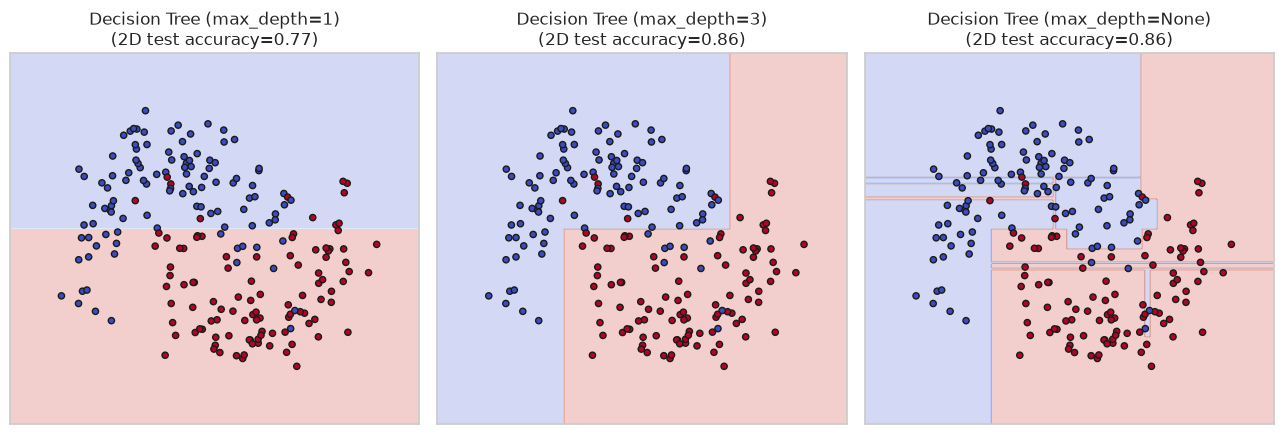

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, depth in zip(axes, [1, 3, None]):
    label = f"max_depth={depth}" if depth else "max_depth=None"
    plot_boundary(DecisionTreeClassifier(max_depth=depth, random_state=2), ax, f"Decision Tree ({label})")
plt.tight_layout()
plt.show()

The boundary is built from axis-aligned rectangular splits — you can see the
"staircase" pattern, especially at `max_depth=None`, which memorizes the
training set almost perfectly (again, classic overfitting).

## 5. Support Vector Machines (SVM)

**Theory.** Finds the hyperplane that maximizes the margin between classes.
With the **kernel trick** (e.g., RBF), it implicitly maps data into a
higher-dimensional space where a linear boundary corresponds to a non-linear
one in the original space — without ever computing that mapping explicitly.
Sensitive to feature scaling.

In [10]:
from sklearn.svm import SVC

evaluate("SVM (RBF kernel)", SVC(kernel="rbf", probability=True, random_state=2))

    SVM (RBF kernel): accuracy=0.982  precision=0.973  recall=1.000  f1=0.986  roc_auc=0.997


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


(SVC(probability=True, random_state=2),
 array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
        1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 1]))

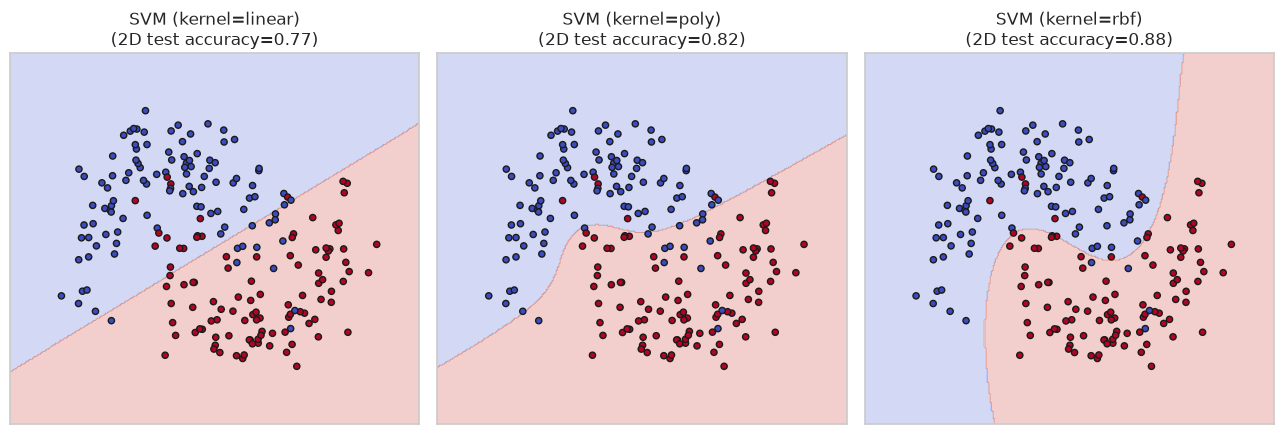

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, kernel in zip(axes, ["linear", "poly", "rbf"]):
    plot_boundary(SVC(kernel=kernel), ax, f"SVM (kernel={kernel})")
plt.tight_layout()
plt.show()

The linear kernel is stuck with a straight line (same limitation as logistic
regression); `poly` and especially `rbf` bend to follow the crescents.

## 6. Random Forest Classifier

**Theory.** Same bagging idea as the regression version: many trees trained
on bootstrapped samples with random feature subsets at each split, combined
by majority vote. Almost always outperforms a single decision tree and needs
little tuning.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model, rf_pred = evaluate("Random Forest", RandomForestClassifier(n_estimators=300, random_state=2))

       Random Forest: accuracy=0.982  precision=0.973  recall=1.000  f1=0.986  roc_auc=0.997


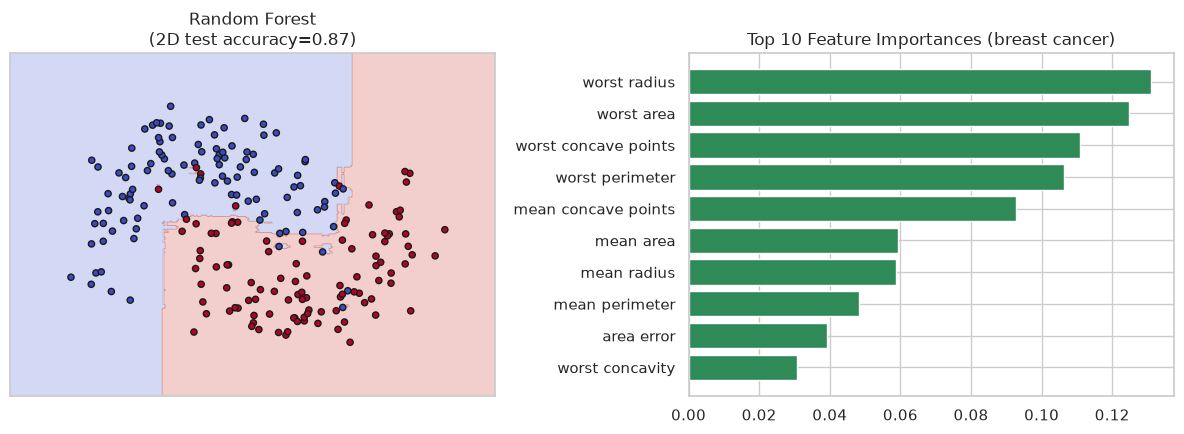

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_boundary(RandomForestClassifier(n_estimators=300, random_state=2), axes[0], "Random Forest")

importances = rf_model.feature_importances_
order = np.argsort(importances)[::-1][:10]
axes[1].barh(np.array(data.feature_names)[order], importances[order], color="seagreen")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Feature Importances (breast cancer)")
plt.tight_layout()
plt.show()

The forest's boundary is smoother than a single tree's (variance reduction
from averaging), while feature importances tell us which measurements
(e.g., "worst area", "worst concave points") drive the diagnosis most.

## 7. Model Comparison

All six classifiers, same breast-cancer train/test split, same metrics.

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.982,0.973,1.000,0.986,0.996
KNN (k=5),0.982,0.973,1.000,0.986,0.973
Random Forest,0.982,0.973,1.000,0.986,0.997
SVM (RBF kernel),0.982,0.973,1.000,0.986,0.997
Decision Tree,0.974,0.973,0.986,0.979,0.992
Naive Bayes,0.965,0.947,1.000,0.973,0.997


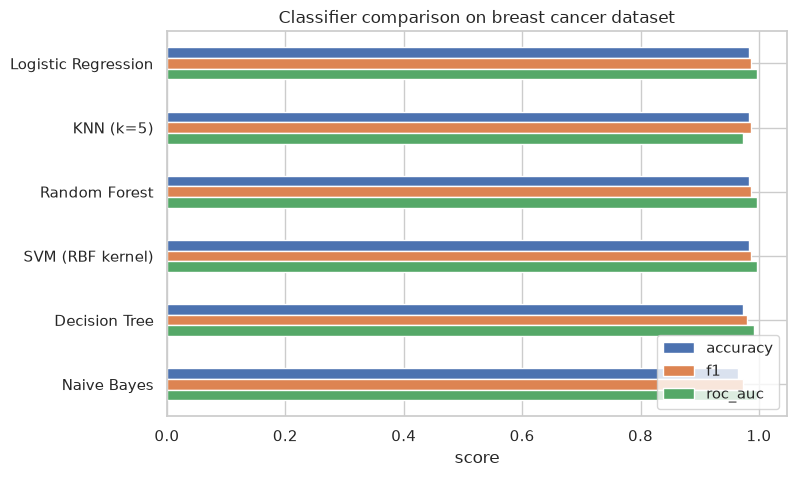

In [14]:
comparison = pd.DataFrame(results).T.sort_values("f1", ascending=False)
display(comparison.round(3))

comparison[["accuracy", "f1", "roc_auc"]].plot.barh(figsize=(8, 5))
plt.gca().invert_yaxis()
plt.xlabel("score")
plt.title("Classifier comparison on breast cancer dataset")
plt.legend(loc="lower right")
plt.show()

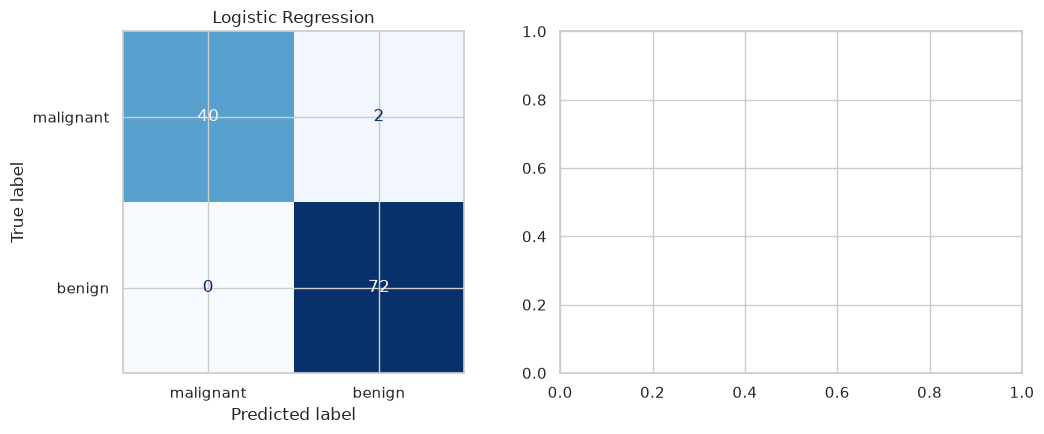

In [15]:
# Confusion matrices side by side for the two strongest models
from sklearn.metrics import ConfusionMatrixDisplay

top_two = comparison.index[:2]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
models = {"Logistic Regression": LogisticRegression(max_iter=5000), "Random Forest": RandomForestClassifier(n_estimators=300, random_state=2)}
for ax, name in zip(axes, top_two):
    model = models.get(name)
    if model is None:
        continue
    model.fit(X_train_s, y_train)
    ConfusionMatrixDisplay.from_estimator(model, X_test_s, y_test, ax=ax, display_labels=data.target_names, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Exercises

1. Re-run the KNN boundary plot with `k=15` — where does it land relative to `k=5` and `k=50`?
2. Try `SVC(kernel="rbf", C=0.1)` vs. `C=100` in the boundary plot — how does `C` (regularization strength) change the boundary's smoothness?
3. Using the breast cancer data, compute precision and recall for `GaussianNB` — which metric is weaker, and what does that imply about its error type (false positives vs. false negatives)?

## Key Takeaways

- Logistic Regression and linear SVM can only draw straight-line boundaries; KNN, Naive Bayes, Trees, RBF-SVM, and Random Forest can all bend to fit non-linear class structure.
- KNN and SVM require feature scaling; tree-based methods (Decision Tree, Random Forest) don't.
- Random Forest is usually a strong default for tabular classification; Naive Bayes is a fast, surprisingly solid baseline.
- Always compare candidates with more than accuracy alone — precision/recall/F1/ROC-AUC can tell very different stories, especially with imbalanced classes (see `07_imbalanced_and_feature_selection`).